In [18]:
import jax
import arviz
import numpy as np
import matplotlib.pyplot as plt
import numpyro
import jaxoplanet
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)


from jaxoplanet.starry.ylm import Ylm
from jaxoplanet.starry.surface import Surface
from jaxoplanet.starry.visualization import show_surface

W0316 11:51:15.198438 29583692 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


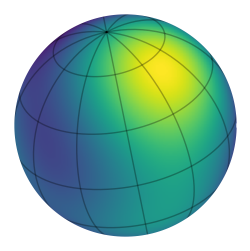

In [7]:
np.random.seed(42)
y = Ylm.from_dense([1.00, *np.random.normal(0.0, 2e-2, size=15)])

u_star = (0.1, 0.1)
surface = Surface(inc=1.0, obl=0.2, period=27.0, u=u_star, y=y)

plt.figure(figsize=(3, 3))
show_surface(surface)

In [10]:
import astropy.units as u
from jaxoplanet.orbits.keplerian import System, Central

system = System(Central())  # a central object with some default parameters

sun = Central(
    radius=1.0,
    mass=1.0,
)

system = System(sun).add_body(
    semimajor=(1.0 * u.au).to(u.R_sun).value,
    radius=(1.0 * u.R_earth).to(u.R_sun).value,
    mass=(1.0 * u.M_earth).to(u.M_sun).value,
)

earth = system.bodies[0]

# checking the parameters of the system
system

System(
  central=Central(mass=1.0, radius=1.0, density=0.238732414637843),
  _body_stack=ObjectStack(...)
)

In [11]:
from jaxoplanet.starry.orbit import SurfaceSystem

system = SurfaceSystem(sun, surface)

In [2]:
from jaxoplanet.orbits.keplerian import System, Central

system = System(Central())  # a central object with some default parameters

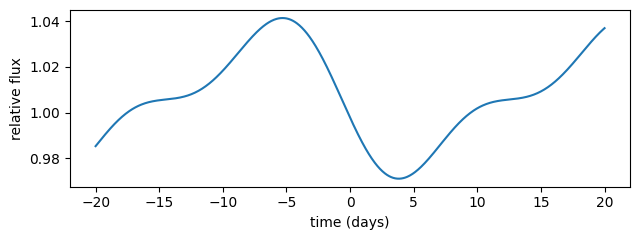

In [14]:
from jaxoplanet.starry.light_curves import light_curve

plt.figure(figsize=(6.5, 2.5))
time = jnp.linspace(-20, 20, 1000)
flux = light_curve(system)(time).T[0]

plt.plot(time, flux)
plt.xlabel("time (days)")
plt.ylabel("relative flux")
plt.tight_layout()

In [15]:
system = SurfaceSystem(sun, surface)

secondary_surface = Surface(
    y=Ylm.from_dense([1.00, *np.random.normal(0.0, 1.0, size=15)])
)

system = system.add_body(
    semimajor=(40.0 * u.au).to(u.R_sun).value,
    radius=(20.0 * u.R_earth).to(u.R_sun).value,
    mass=(1.0 * u.M_earth).to(u.M_sun).value,
    impact_param=0.2,
    surface=secondary_surface,
)

In [16]:
t_start, t_end = -20, 20
n = 1000
time = jnp.linspace(t_start, t_end, n)
flux = light_curve(system)(time).T[0]

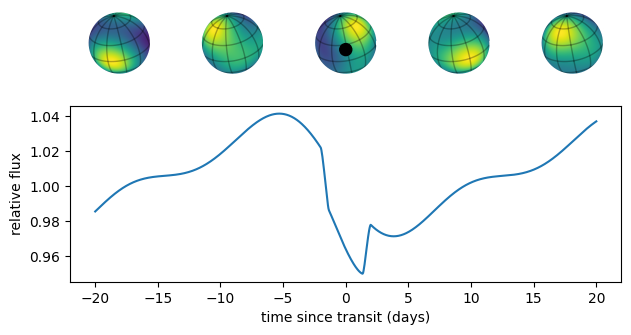

In [17]:
n_plots = 5
times = jnp.linspace(t_start, t_end, n_plots)
radius_ratio = system.bodies[0].radius / system.central.radius
gs = plt.GridSpec(2, n_plots)

plt.figure(figsize=(6.5, 4.0))

for i in range(n_plots):
    ax = plt.subplot(gs[0, i])
    phase = surface.rotational_phase(times[i])
    x, y = system.bodies[0].position(times[i])[0:2]
    show_surface(surface, ax=ax, theta=phase)
    circle = plt.Circle((x, y), radius_ratio, color="k", fill=True, zorder=10)
    ax.add_artist(circle)
    ax.set_xlim(-1.5, 1.5)

plt.subplot(gs[1, :])
plt.plot(time, flux)

plt.xlabel("time since transit (days)")
plt.ylabel("relative flux")
plt.tight_layout()

In [3]:
system = system.add_body(period=0.1)

In [4]:
system

System(
  central=Central(mass=1.0, radius=1.0, density=0.238732414637843),
  _body_stack=ObjectStack(...)
)

In [5]:
from jaxoplanet.starry import Surface, Ylm
from jaxoplanet.starry.light_curves import surface_light_curve
import jax.numpy as jnp
import matplotlib.pyplot as plt
radii = [0.01, 0.1, 1.0]
orders = jnp.logspace(jnp.log10(5), jnp.log10(1000), 6).astype(int).tolist()

# degree of the spherical harmonics map
l_max = 3

# a dummy surface described by unitary coefficients (not physical)
y = Ylm.from_dense(jnp.ones((l_max + 1) ** 2))
surface = Surface(y=y, u=(1.0, 1.0))

r = 1.0
b = 1.0

reference = surface_light_curve(surface=surface, y=b, r=r, z=1.0, order=1500)
calc = surface_light_curve(surface=surface, y=b, r=r, z=1.0, order=10)

print(f"precision: {abs(calc - reference):.2e}")

precision: 5.48e-05


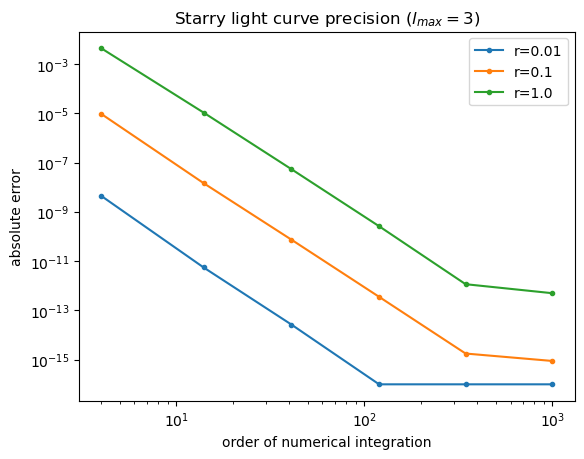

In [6]:
def estimate_precision(r=0.1):
    # values of b for which we expect the maximum error
    b = r if r > 1 else 1.0
    reference = surface_light_curve(surface=surface, y=b, r=r, z=1.0, order=1500)

    def fun(order):
        calc = surface_light_curve(surface=surface, y=b, r=r, z=1.0, order=order)
        result = jnp.abs(reference - calc)
        return max(result, 1e-16)

    return fun


with jax.disable_jit():
    precision = {r: [estimate_precision(r)(order) for order in orders] for r in radii}

for i, r in enumerate(radii):
    plt.plot(orders, precision[r], ".-", label=f"r={r}")

plt.yscale("log")
plt.xscale("log")
plt.xlabel("order of numerical integration")
plt.ylabel("absolute error")
plt.title(f"Starry light curve precision ($l_{{max}}={l_max}$)")
_ = plt.legend()